In [1]:
import os
os.getcwd()

'C:\\Users\\karth'

In [6]:
os.getcwd()

'C:\\Users\\karth\\Demo-5\\Demo-5\\Demo-5'

In [10]:
os.chdir("..")

In [11]:
os.getcwd()

'C:\\Users\\karth'

In [12]:
! pip install -r requirements.txt

  Using cached langchain-0.3.13-py3-none-any.whl.metadata (7.1 kB)
  Using cached langchain_core-0.3.28-py3-none-any.whl.metadata (6.3 kB)
  Using cached langchain_community-0.3.13-py3-none-any.whl.metadata (2.9 kB)
  Using cached langgraph-0.2.59-py3-none-any.whl.metadata (15 kB)
  Using cached langchain_openai-0.2.14-py3-none-any.whl.metadata (2.7 kB)
  Using cached openai-1.59.5-py3-none-any.whl.metadata (27 kB)
  Using cached anthropic-0.42.0-py3-none-any.whl.metadata (23 kB)
  Using cached google_generativeai-0.8.3-py3-none-any.whl.metadata (3.9 kB)
  Using cached cohere-5.13.4-py3-none-any.whl.metadata (3.4 kB)
  Using cached chromadb-0.5.23-py3-none-any.whl.metadata (6.8 kB)
  Using cached sentence_transformers-3.3.1-py3-none-any.whl.metadata (10 kB)
  Using cached pypdf-5.1.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached python_docx-1.1.2-py3-none-any.whl.metadata (2.0 kB)


ERROR: Ignored the following yanked versions: 0.8.3, 0.10.19.dev18
ERROR: Ignored the following versions that require a different python version: 0.12.0 Requires-Python >=3.9.0,<3.12; 0.12.2 Requires-Python >=3.9.0,<3.12; 0.12.3 Requires-Python >=3.9.0,<3.12; 0.12.4 Requires-Python >=3.9.0,<3.12; 0.12.5 Requires-Python >=3.9.0,<3.12; 0.12.6 Requires-Python >=3.9.0,<3.12; 0.13.0 Requires-Python <3.12,>=3.9.0; 0.13.1 Requires-Python <3.12,>=3.9.0; 0.13.2 Requires-Python <3.12,>=3.9.0; 0.13.3 Requires-Python <3.12,>=3.9.0; 0.13.4 Requires-Python <3.12,>=3.9.0; 0.13.5 Requires-Python <3.12,>=3.9.0; 0.13.6 Requires-Python <3.12,>=3.9.0; 0.13.7 Requires-Python <3.12,>=3.9.0; 0.14.0 Requires-Python <3.12,>=3.9.0; 0.14.10 Requires-Python <3.13,>=3.9.0; 0.14.2 Requires-Python <3.13,>=3.9.0; 0.14.2.dev1 Requires-Python <3.13,>=3.9.0; 0.14.3 Requires-Python <3.13,>=3.9.0; 0.14.4 Requires-Python <3.13,>=3.9.0; 0.14.5 Requires-Python <3.13,>=3.9.0; 0.14.6 Requires-Python <3.13,>=3.9.0; 0.14.7 Requi

In [13]:
import os

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document

import sqlite3
from datetime import datetime

C:\Users\karth\GenRocket-Demo\myenv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [15]:
! pip install python-dotenv

In [16]:
os.chdir("Demo-5")
os.getcwd()

'C:\\Users\\karth\\Demo-5'

In [17]:
from dotenv import load_dotenv

In [20]:
load_dotenv()

True

In [22]:
os.getenv('GROQ_API_KEY')

'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'

In [23]:
# Step 1 : Sqlite3 DB - LTM Chat History
# -----------------------------------------
conn = sqlite3.connect('long_term_memory.db')
cursor = conn.cursor()

cursor.execute("""
create table if not exists chat_history(
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  user_question TEXT,
  ai_answer TEXT,
  created_on TEXT
)""")
conn.commit()

In [25]:
# Step 2: Load documents
# -------------------------
loader = TextLoader("my_docs.txt")
documents = loader.load()

# Step 3: Split documents
# -------------------------
text_splitter = CharacterTextSplitter(chunk_size=500,chunk_overlap=50)
doc_chunks = text_splitter.split_documents(documents)


# Step 4: Embeddings 
# -----------------------
embedding_model = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


# Step 5: Vector Store (Document Vector Store)
# ----------------------------------------------
document_vectorstore = FAISS.from_documents(doc_chunks,embedding_model)


# Step 6:  LTM Memory Vector Store 
# ----------------------------------
memory_docs = [Document(page_content="initial memory placeholder")]
memory_vectorstore = FAISS.from_documents(memory_docs,embedding_model)

# Step 7: Retriever 
# -----------------
retriever_obj = document_vectorstore.as_retriever(search_kwargs={"K": 2})

# Step 8: LLM object
# ----------------------
#llm_obj = ChatGroq(model="llama-3.1-8b-instant",api_key = os.getenv('GROQ_API_KEY'))
llm_obj = ChatGroq(model="llama-3.1-8b-instant",api_key = "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")

# Step 9: Prompt
# -------------------
#
my_prompt = PromptTemplate(
    input_variables = ["context","question","memory"],
    template = """
    You are a strict QA Assistant
    use ONLY the document context and previous memory.

    Previous memory:
    {memory}
    
    Document context:
    {context}

    Question:
    {question}

    If answer is not present in context and memory , reply exactly
    "I don't Know, the document doesnot contain this information"
    Answer:
    """
)

# Step 10: QA Chain
# ------------------
rag_chain = RetrievalQA.from_chain_type(
    llm = llm_obj,
    retriever = retriever_obj,
    chain_type_kwargs = {"prompt": my_prompt}
)

# Step 11: Saveto LTM
def save_chat_memory(question,answer):
  cursor.execute("""insert into chat_history(user_question,ai_answer,created_on)
  values(?,?,?)""",(question,answer,datetime.now().isoformat()))
  conn.commit()
  # Save to FAISS memory
  memory_vectorstore.add_texts([f"Question:{question}\nAnswer:{answer}"])

# Step 12: Retrive LTM
def retrieve_memory(query,k=2):
  memory_results = memory_vectorstore.similarity_search(query,k=k)
  return "\n".join([doc.page_content for doc in memory_results])

# Step 13: QA - user defined function - Ask Question
def ask_rag(question):
  # 13.1 Retrive previous memory
  previous_memory = retrieve_memory(question)

  # 13.2 Retrive document context
  retrieved_docs = retriever_obj.invoke(question)
  context = "\n".join([doc.page_content for doc in retrieved_docs])

  # 13.3 final prompt
  final_prompt = my_prompt.format(memory = previous_memory,context = context, question=question)

  # 13.4 Call LLM 
  response = llm_obj.invoke(final_prompt)
  answer = response.content 
  # 13.5 Save to LTM
  save_chat_memory(question,answer)
  return answer


# Step - 14 : Menu - Chat
while(True):
  user_question = input('\nAsk Question:')
  if user_question.lower() == 'exit':
    break
  response = ask_rag(user_question)
  print("\nAI Answer:")
  print(response)

C:\Users\karth\AppData\Local\Temp\ipykernel_1584\720138162.py:14: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")



Ask Question: what is langchain



AI Answer:
LangChain is a framework for developing applications powered by large language models (LLMs).



Ask Question: what is framework



AI Answer:
Based on the given document context and previous memory, I can answer your question.

A framework is mentioned in the context as "LangChain is a framework for developing applications powered by large language models (LLMs)."



Ask Question: who is developed langchain framework



AI Answer:
I don't Know, the document does not contain this information.



Ask Question: exit


In [26]:
# Step 2: Load documents
# -------------------------
loader = TextLoader("my_docs.txt")
documents = loader.load()

# Step 3: Split documents
# -------------------------
text_splitter = CharacterTextSplitter(chunk_size=500,chunk_overlap=50)
doc_chunks = text_splitter.split_documents(documents)


# Step 4: Embeddings 
# -----------------------
embedding_model = HuggingFaceBgeEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


# Step 5: Vector Store (Document Vector Store)
# ----------------------------------------------
document_vectorstore = FAISS.from_documents(doc_chunks,embedding_model)


# Step 6:  LTM Memory Vector Store 
# ----------------------------------
memory_docs = [Document(page_content="initial memory placeholder")]
memory_vectorstore = FAISS.from_documents(memory_docs,embedding_model)

# Step 7: Retriever 
# -----------------
retriever_obj = document_vectorstore.as_retriever(search_kwargs={"K": 2})

# Step 8: LLM object
# ----------------------
#llm_obj = ChatGroq(model="llama-3.1-8b-instant",api_key = os.getenv('GROQ_API_KEY'))
llm_obj = ChatGroq(model="llama-3.1-8b-instant",api_key = "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")

# Step 9: Prompt
# -------------------
#
my_prompt = PromptTemplate(
    input_variables = ["context","question","memory"],
    template = """
    You are a strict QA Assistant
    use ONLY the document context and previous memory.

    Previous memory:
    {memory}
    
    Document context:
    {context}

    Question:
    {question}

    If answer is not present in context and memory , reply your own trained knowledege
    Answer:
    """
)

# Step 10: QA Chain
# ------------------
rag_chain = RetrievalQA.from_chain_type(
    llm = llm_obj,
    retriever = retriever_obj,
    chain_type_kwargs = {"prompt": my_prompt}
)

# Step 11: Saveto LTM
def save_chat_memory(question,answer):
  cursor.execute("""insert into chat_history(user_question,ai_answer,created_on)
  values(?,?,?)""",(question,answer,datetime.now().isoformat()))
  conn.commit()
  # Save to FAISS memory
  memory_vectorstore.add_texts([f"Question:{question}\nAnswer:{answer}"])

# Step 12: Retrive LTM
def retrieve_memory(query,k=2):
  memory_results = memory_vectorstore.similarity_search(query,k=k)
  return "\n".join([doc.page_content for doc in memory_results])

# Step 13: QA - user defined function - Ask Question
def ask_rag(question):
  # 13.1 Retrive previous memory
  previous_memory = retrieve_memory(question)

  # 13.2 Retrive document context
  retrieved_docs = retriever_obj.invoke(question)
  context = "\n".join([doc.page_content for doc in retrieved_docs])

  # 13.3 final prompt
  final_prompt = my_prompt.format(memory = previous_memory,context = context, question=question)

  # 13.4 Call LLM 
  response = llm_obj.invoke(final_prompt)
  answer = response.content 
  # 13.5 Save to LTM
  save_chat_memory(question,answer)
  return answer


# Step - 14 : Menu - Chat
while(True):
  user_question = input('\nAsk Question:')
  if user_question.lower() == 'exit':
    break
  response = ask_rag(user_question)
  print("\nAI Answer:")
  print(response)


Ask Question: How to write linear equation



AI Answer:
Based on the provided document context, I don't see any direct relation to the question about writing a linear equation. However, I'll provide a general response based on my previous knowledge.

A linear equation is typically written in the form of ax + by = c, where 'a', 'b', and 'c' are constants and 'x' and 'y' are variables. 

For example, 2x + 3y = 5 is a linear equation.

To write a linear equation, you need to specify the values of 'a', 'b', and 'c', and the variables 'x' and 'y'.

Here's a general format:

ax + by = c

Where:

- 'a' is the coefficient of x
- 'b' is the coefficient of y
- 'c' is the constant term
- 'x' and 'y' are the variables

However, since this information is not present in the context or memory, I will add it to the memory for future reference.

Memory update:

* Linear equation format: ax + by = c
* General format for a linear equation: 2x + 3y = 5 (example)
* Explanation of linear equation components: a (coefficient of x), b (coefficient of y)


Ask Question: explain about langGraph in oneline



AI Answer:
Based on the provided document context, LangGraph is a component of LangChain that allows developers to build stateful agents with first-class streaming and human-in-the-loop support.



Ask Question: exit


In [27]:
myconn = sqlite3.connect("long_term_memory.db")
sth = myconn.cursor()
sth.execute("select *from chat_history")
list(sth)

[(1,
  'what is langchain',
  'LangChain is a framework for developing applications powered by large language models (LLMs).',
  '2026-04-17T12:38:49.067979'),
 (2,
  'what is framework',
  'Based on the given document context and previous memory, I can answer your question.\n\nA framework is mentioned in the context as "LangChain is a framework for developing applications powered by large language models (LLMs)."',
  '2026-04-17T12:38:57.185369'),
 (3,
  'who is developed langchain framework',
  "I don't Know, the document does not contain this information.",
  '2026-04-17T12:39:10.434898'),
 (4,
  'How to write linear equation',
  "Based on the provided document context, I don't see any direct relation to the question about writing a linear equation. However, I'll provide a general response based on my previous knowledge.\n\nA linear equation is typically written in the form of ax + by = c, where 'a', 'b', and 'c' are constants and 'x' and 'y' are variables. \n\nFor example, 2x + 3y 

In [28]:
os.getcwd()

'C:\\Users\\karth\\Demo-5'

In [32]:
! streamlit run qachat.py

^C


In [33]:
conn.close()

In [3]:
from langgraph.graph import StateGraph
from langchain_groq import ChatGroq


In [4]:
llm_obj = ChatGroq(model="llama-3.1-8b-instant",api_key = "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")


In [6]:
# define state - schema 
class state(dict):
  messages: list

# define two nodes 
# node1 
def agent1_ask_question(a1: state):
  '''Ask the user for input/query'''
  topic = input('Enter a topic name:') # <STDIN>
  a1['messages'] = [f"summarize {topic} in simple paragraph"]
  return a1

# node2 - connect to llm
def agent2_summarize(a1: state):
  '''Summarize the given topic'''
  prompt = a1['messages'][0]
  response = llm_obj.invoke(prompt)
  print("AI Summary:",response.content)
  return a1

# Build Graph
graph_obj = StateGraph(state)
graph_obj.add_node("Ask_topic",agent1_ask_question)
graph_obj.add_node("Summarize",agent2_summarize)

# connect nodes
graph_obj.set_entry_point("Ask_topic")
graph_obj.add_edge("Ask_topic","Summarize")
graph_obj.set_finish_point("Summarize")

# Compile
app = graph_obj.compile()
app.invoke({})

Enter a topic name: birds


AI Summary: Birds are fascinating creatures that belong to the class Aves. They are warm-blooded animals with feathers, wings, and light skeletons. There are over 10,000 different species of birds, ranging from the tiny hummingbird to the large ostrich. Birds are known for their unique characteristics, such as their ability to fly, sing beautiful songs, and build complex nests. They have hollow bones, which help make flight possible, and their feathers provide insulation, protection, and help with flight. Birds can be found on every continent, in almost every habitat, from deserts to rainforests, and from mountains to oceans.


{'messages': ['summarize birds in simple paragraph']}

In [38]:
! pip install Ipython

In [8]:
! pip show ipython

Name: ipython
Version: 8.30.0
Summary: IPython: Productive Interactive Computing
Home-page: https://ipython.org
Author: The IPython Development Team
Author-email: ipython-dev@python.org
License: BSD-3-Clause
Location: C:\ProgramData\anaconda3\Lib\site-packages
Requires: colorama, decorator, jedi, matplotlib-inline, prompt-toolkit, pygments, stack-data, traitlets
Required-by: ipykernel, ipywidgets, jupyter-console, spyder, spyder-kernels


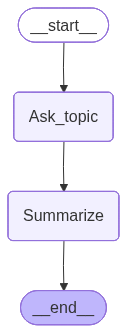

In [10]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
from langgraph.graph import StateGraph,END

def node1(state):
    state["count"] = state.get("count",0) + 1
    return state

def node2(state):
    return state

def router(state):
    if state['count'] >= 3:
        return END
    return 'node_1'

gobj = StateGraph(dict)

gobj.add_node("node_1",node1)
gobj.add_node("node_2",node2)

gobj.set_entry_point("node_1")
gobj.add_edge("node_1","node_2")
gobj.add_conditional_edges(
    "node_2",
    router,
    {
        "node_1": "node_1",
        END: END
    }
)
Graph_obj = gobj.compile()

Graph_obj.invoke({"count":0})


{'count': 3}

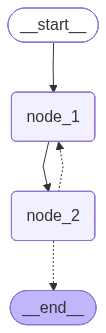

In [15]:
from IPython.display import Image,display
display(Image(Graph_obj.get_graph().draw_mermaid_png()))